# Rangeland Dynamics & Land Degradation — Experimentation Lab

**Module:** `arin_climate_dss.land_degradation`
**Study area:** Northern Burkina Faso, Sahel — Bam & Soum provinces
**Analysis period:** 2015-01-01 → 2024-12-31 (10 years)
**Architecture role:** Domain layer — feeds `LandDegradationUseCase` in `use_case.py`

---

## Pipeline

| § | Step | Source |
|---|------|--------|
| 1 | Study Area & GEE Init | EPSG:4326 bounding box |
| 2 | MODIS NDVI — Monthly → Annual Aggregation | MOD13A3 500 m (`MODIS/061/MOD13A3`) |
| 3 | Pixel-Wise NDVI Trend Stack | GEE `linearFit` → slope / mean / CV |
| 4 | Spectral Indices: BSI & NDTI |(1 000 m) |
| 5 | Terrain Slope | SRTM 30 m → 1 000 m (`USGS/SRTMGL1_003`) |
| 6 | Rainfall Anomaly | CHIRPS daily → 1 000 m (`UCSB-CHG/CHIRPS/DAILY`) |
| 7 | Land Cover | ESA WorldCover 2021 (`ESA/WorldCover/v200`) |
| 8 | Feature Stack & Point Sampling | GEE `.sample()` at 1 000 m → pandas |
| 9 | NDVI Annual OLS Trend + Mann-Kendall | scipy — one value per year |
| 10 | Structural Breakpoint Detection | `ruptures` Binseg (RBF, annual series) |
| 11 | Degradation Scoring & Labelling | Composite score → 4-class labels |
| 12 | Feature EDA | Distributions + correlation matrix |
| 13 | **Random Forest Classifier** | scikit-learn |
| 14 | **LightGBM Classifier** | lightgbm |
| 15 | **Hyperparameter Tuning** | Optuna TPE (20 trials) |
| 16 | **SHAP Feature Importance** | shap TreeExplainer |
| 17 | Result Packaging | JSON-serialisable DSS payload |

---

**Data extraction pattern:** GEE image → `.sample()` → pandas (features);
GEE `reduceRegion` → annual mean (NDVI time series).

**Output schema** (matches `LandDegradationUseCase.run()`):
```
{
  stats:      { model_type, n_pixels, test_f1, ndvi_trend_per_year, mk_tau, … }
  riskDist:   { labels, data, data_ha, colors }
  timeSeries: { labels, datasets: [{label, data, color}] }
  shap:       { features, mean_abs_shap }
  raster:     { degradation_risk: 'outputs/…_degradation_risk.tif' }
}
```

In [1]:
import io
import json
from math import ceil
from pathlib import Path

import ee
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import requests
import rioxarray as rxr
import ruptures as rpt
import seaborn as sns
import shap
import xarray as xr
from ruptures.utils import sanity_check
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler

print("Packages imported successfully!")

Packages imported successfully!


In [2]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
plt.rcParams.update(
    {"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False}
)

DEGRADATION_CLASSES = ["Not Degraded", "Degraded"]
DEGRADATION_COLORS = ["#2ECC71", "#E74C3C"]
DEGRADATION_THRESHOLDS = [None]  # set dynamically in §11 (70th-pct of score)

FEATURE_COLS = [
    "ndvi_slope",  # NDVI yr⁻¹  — primary degradation signal
    "ndvi_mean",  # Annual mean NDVI — baseline productivity
    "ndvi_cv",  # Coefficient of variation — inter-annual instability
    "bsi",  # Bare Soil Index (Sentinel-2)
    "ndti",  # Normalised Difference Tillage Index
    "slope_terrain",  # Terrain slope (degrees) — erosion risk
    "rainfall_anom",  # Rainfall trend slope (mm yr⁻¹)
    "land_cover",  # ESA WorldCover class code (normalised)
]

print("Environment ready.")

Environment ready.


In [3]:
ee.Authenticate()
ee.Initialize(project="parallelprocessing-433914")

---
## §1 — Study Area: Northern Burkina Faso, Sahel

**Provinces:** Bam (Centre-Nord) and Soum (Sahel) — semi-arid Sahelian rangelands.
Annual rainfall 400–700 mm; dominant land use is rain-fed agriculture and extensive pastoralism.

All feature rasters are sampled at **1 000 m** — consistent with the analysis scale for
national-level land degradation assessments (UNCCD / WOCAT standard).

In [4]:
# Northern Burkina Faso — [lon_min, lat_min, lon_max, lat_max]
bbox = [-2.5, 12.5, 1.5, 15.0]
aoi = ee.Geometry.Rectangle(bbox)

area_km2 = aoi.area().divide(1e6).getInfo()
print(f"AOI  : {bbox}")
print(f"Area : {area_km2:,.0f} km²")

START = "2015-01-01"
END = "2024-12-31"
SCALE = 1000  # metres — uniform for all feature rasters
N_PIXELS = 3000  # point sample size for modelling

AOI  : [-2.5, 12.5, 1.5, 15.0]
Area : 120,131 km²


---
## §2 — MODIS NDVI: Monthly Fetch → Annual Aggregation

Source: **MODIS MOD13A3** 500 m (`MODIS/061/MOD13A3`).

Monthly area-averaged NDVI is fetched via server-side `reduceRegion`, then aggregated to
**annual means** in Python. Annual values remove seasonal noise and represent inter-annual
vegetation productivity — the correct signal for land degradation trend detection.

In [5]:
def _scale_ndvi(img):
    return img.multiply(0.0001).copyProperties(img, ["system:time_start"])


modis = (
    ee.ImageCollection("MODIS/061/MOD13A3")
    .filterBounds(aoi)
    .filterDate(START, END)
    .select("NDVI")
    .map(_scale_ndvi)
)

In [6]:
def _mean_feat(img):
    v = img.reduceRegion(ee.Reducer.mean(), aoi, 500, maxPixels=1e9)
    return ee.Feature(None, v).set("date", img.date().format("YYYY-MM"))


records = ee.FeatureCollection(modis.map(_mean_feat)).getInfo()["features"]

In [7]:
ts_df = pd.DataFrame([f["properties"] for f in records]).sort_values("date").dropna()

# Monthly series
ndvi_ts = pd.Series(
    ts_df["NDVI"].values,
    index=pd.to_datetime(ts_df["date"]),
    name="NDVI",
)

# Annual aggregation — one value per year
ndvi_annual = ndvi_ts.resample("YE").mean()
ndvi_annual.index = ndvi_annual.index.year.astype(int)  # index = [2015…2024]

print(f"Monthly obs  : {len(ndvi_ts)}")
print(f"Annual obs   : {len(ndvi_annual)}")
print(f"Annual range : [{ndvi_annual.min():.4f}, {ndvi_annual.max():.4f}]")
print()
print(ndvi_annual.to_string())

Monthly obs  : 120
Annual obs   : 10
Annual range : [0.2307, 0.2756]

date
2015    0.234412
2016    0.233806
2017    0.230681
2018    0.235533
2019    0.232736
2020    0.249252
2021    0.246808
2022    0.251928
2023    0.258688
2024    0.275637


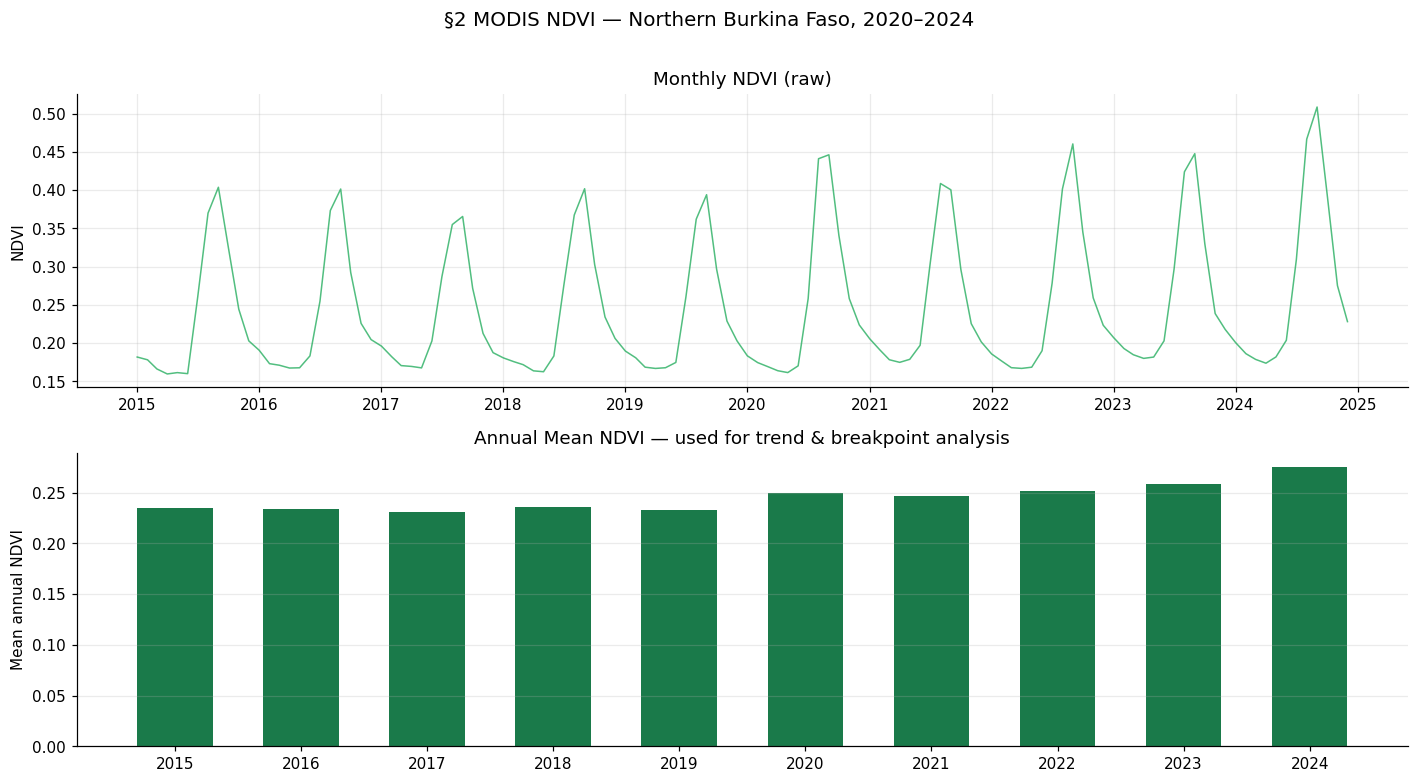

In [8]:
# Visualise the raw Yearly NDVI
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=False)

axes[0].plot(ndvi_ts.index, ndvi_ts.values, color="#27AE60", lw=1.0, alpha=0.8)
axes[0].set_ylabel("NDVI")
axes[0].set_title("Monthly NDVI (raw)")
axes[0].grid(alpha=0.25)

axes[1].bar(ndvi_annual.index, ndvi_annual.values, color="#1A7A4A", width=0.6)
axes[1].set_ylabel("Mean annual NDVI")
axes[1].set_title("Annual Mean NDVI — used for trend & breakpoint analysis")
axes[1].set_xticks(ndvi_annual.index)
axes[1].grid(axis="y", alpha=0.25)

plt.suptitle("§2 MODIS NDVI — Northern Burkina Faso, 2020–2024", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## §3 — Pixel-Wise NDVI Trend Stack

Server-side `linearFit` reducer computes per-pixel OLS regression of NDVI against time.
Monthly MODIS data is used here (more observations = more robust per-pixel slope).
Downloaded as a 3-band GeoTIFF at 1 000 m: **slope / mean / CV**.

| Band | Meaning | High value = |
|------|---------|-------------|
| `ndvi_slope` | NDVI change per year | Recovery (+) or decline (−) |
| `ndvi_mean` | Temporal mean NDVI | Dense, productive vegetation |
| `ndvi_cv` | Std / Mean | Unstable inter-annual signal |

In [9]:
def _add_time(img):
    t = img.date().difference(ee.Date(START), "year")
    return img.addBands(ee.Image(t).rename("time").float())


trend_img = modis.map(_add_time).select(["time", "NDVI"]).reduce(ee.Reducer.linearFit())
slope_img = trend_img.select("scale").rename("ndvi_slope")
mean_img = modis.mean().rename("ndvi_mean")
std_img = modis.reduce(ee.Reducer.stdDev()).rename("ndvi_stddev")
cv_img = std_img.divide(mean_img.abs().add(1e-6)).rename("ndvi_cv")

In [10]:
ndvi_stack = slope_img.addBands(mean_img).addBands(cv_img)

url = ndvi_stack.getDownloadURL(
    {"region": aoi, "scale": SCALE, "crs": "EPSG:4326", "format": "GEO_TIFF"}
)

In [11]:
response = requests.get(url)
response.raise_for_status()
ndvi_raw = rxr.open_rasterio(io.BytesIO(response.content))
ndvi_raw = ndvi_raw.assign_coords(band=["ndvi_slope", "ndvi_mean", "ndvi_cv"])
ndvi_ds = ndvi_raw.to_dataset(dim="band").rename({"x": "lon", "y": "lat"})
ndvi_ds

<xarray.Dataset> Size: 3MB
Dimensions:      (lat: 280, lon: 446)
Coordinates:
  * lon          (lon) float64 4kB -2.502 -2.493 -2.484 ... 1.478 1.487 1.496
  * lat          (lat) float64 2kB 15.01 15.0 14.99 14.98 ... 12.52 12.51 12.5
    spatial_ref  int64 8B 0
Data variables:
    ndvi_slope   (lat, lon) float64 999kB ...
    ndvi_mean    (lat, lon) float64 999kB ...
    ndvi_cv      (lat, lon) float64 999kB ...
Attributes:
    AREA_OR_POINT:           Area
    TIFFTAG_RESOLUTIONUNIT:  1 (unitless)
    TIFFTAG_XRESOLUTION:     1
    TIFFTAG_YRESOLUTION:     1
    scale_factor:            1.0
    add_offset:              0.0

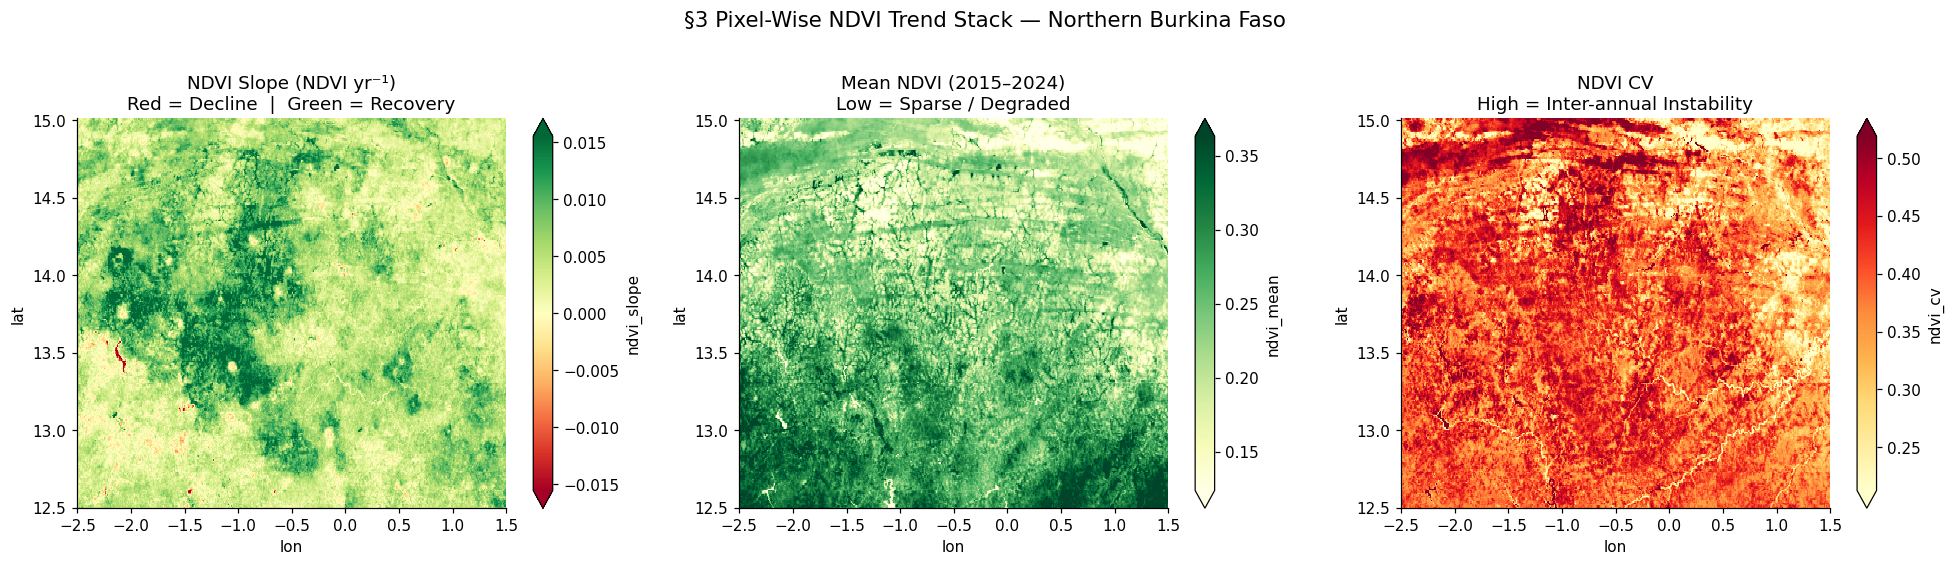

In [12]:
# Visualise the yearly rate of change (gradient/slope, mean, and CV) of NDVI
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ndvi_ds["ndvi_slope"].plot(ax=axes[0], cmap="RdYlGn", robust=True)
axes[0].set_title("NDVI Slope (NDVI yr⁻¹)\nRed = Decline  |  Green = Recovery")

ndvi_ds["ndvi_mean"].plot(ax=axes[1], cmap="YlGn", robust=True)
axes[1].set_title("Mean NDVI (2015–2024)\nLow = Sparse / Degraded")

ndvi_ds["ndvi_cv"].plot(ax=axes[2], cmap="YlOrRd", robust=True)
axes[2].set_title("NDVI CV\nHigh = Inter-annual Instability")

plt.suptitle(
    "§3 Pixel-Wise NDVI Trend Stack — Northern Burkina Faso", fontsize=14, y=1.02
)
plt.tight_layout()
plt.show()

In [13]:
plt.savefig("../experiments/outputs/rl_ndvi_trend_stack.png", dpi=150)

<Figure size 704x528 with 0 Axes>

---
## §4 — Sentinel-2 Spectral Indices: BSI & NDTI (Annual Composites)

**Source:** GEE `COPERNICUS/S2_SR_HARMONIZED` — one annual median composite per year (2015–2024).  
Each composite uses scenes from the full calendar year with cloud cover < 30 %.  
**Resolution:** 1 000 m, matching all other feature layers.  
**Output:** 10 annual images per index (20 bands total) downloaded as a single GeoTIFF.

| Index | Formula | High value = |
|-------|---------|-------------|
| **BSI** | (SWIR1 + Red − NIR − Blue) / (SWIR1 + Red + NIR + Blue) | Bare/degraded soil |
| **NDTI** | (SWIR1 − SWIR2) / (SWIR1 + SWIR2) | Residue / litter cover |

`bsi_img` / `ndti_img` (temporal mean across all 10 years) are passed to §8 for server-side `.sample()`.

In [14]:
s2_years = list(range(int(START[:4]), int(END[:4]) + 1))  # [2015 … 2024]

In [15]:
def _annual_indices(year):
    col = (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterBounds(aoi)
        .filterDate(f"{year}-01-01", f"{year}-12-31")
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 30))
        .select(["B2", "B4", "B8", "B11", "B12"])
        .map(lambda i: i.multiply(0.0001))
        .median()
        .clip(aoi)
    )
    bsi = col.expression(
        "(SWIR1 + RED - NIR - BLUE) / (SWIR1 + RED + NIR + BLUE)",
        {
            "SWIR1": col.select("B11"),
            "RED": col.select("B4"),
            "NIR": col.select("B8"),
            "BLUE": col.select("B2"),
        },
    ).rename(f"bsi_{year}")
    ndti = col.expression(
        "(SWIR1 - SWIR2) / (SWIR1 + SWIR2)",
        {"SWIR1": col.select("B11"), "SWIR2": col.select("B12")},
    ).rename(f"ndti_{year}")
    return bsi, ndti

In [16]:
bsi_ee_list, ndti_ee_list = [], []
for yr in s2_years:
    b, n = _annual_indices(yr)
    bsi_ee_list.append(b)
    ndti_ee_list.append(n)

# 20-band stack: 10 BSI + 10 NDTI — all at 1 000 m (~9 MB)
combined = ee.Image.cat(bsi_ee_list + ndti_ee_list)

In [17]:
url = combined.getDownloadURL(
    {"region": aoi, "scale": 5000, "crs": "EPSG:4326", "format": "GEO_TIFF"}
)
response = requests.get(url)
response.raise_for_status()

In [18]:
band_names = [f"bsi_{yr}" for yr in s2_years] + [f"ndti_{yr}" for yr in s2_years]
s2_raw = rxr.open_rasterio(io.BytesIO(response.content))
s2_raw = s2_raw.assign_coords(band=band_names)
s2_ds = s2_raw.to_dataset(dim="band").rename({"x": "lon", "y": "lat"})

Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.


In [19]:
# Temporal mean composites — single-band GEE images used by §8 .sample()
bsi_img = ee.Image.cat(bsi_ee_list).reduce(ee.Reducer.mean()).rename("bsi")
ndti_img = ee.Image.cat(ndti_ee_list).reduce(ee.Reducer.mean()).rename("ndti")

print(
    f"Downloaded {len(s2_years)} annual composites × 2 indices = {len(band_names)} bands"
)
print(s2_ds)

Downloaded 10 annual composites × 2 indices = 20 bands
<xarray.Dataset> Size: 808kB
Dimensions:      (lat: 56, lon: 90)
Coordinates:
  * lon          (lon) float64 720B -2.493 -2.448 -2.403 ... 1.415 1.46 1.505
  * lat          (lat) float64 448B 14.98 14.93 14.89 14.84 ... 12.6 12.55 12.51
    spatial_ref  int64 8B 0
Data variables: (12/20)
    bsi_2015     (lat, lon) float64 40kB ...
    bsi_2016     (lat, lon) float64 40kB ...
    bsi_2017     (lat, lon) float64 40kB ...
    bsi_2018     (lat, lon) float64 40kB ...
    bsi_2019     (lat, lon) float64 40kB ...
    bsi_2020     (lat, lon) float64 40kB ...
    ...           ...
    ndti_2019    (lat, lon) float64 40kB ...
    ndti_2020    (lat, lon) float64 40kB ...
    ndti_2021    (lat, lon) float64 40kB ...
    ndti_2022    (lat, lon) float64 40kB ...
    ndti_2023    (lat, lon) float64 40kB ...
    ndti_2024    (lat, lon) float64 40kB ...
Attributes:
    AREA_OR_POINT:           Area
    TIFFTAG_RESOLUTIONUNIT:  1 (unitless)
    TI

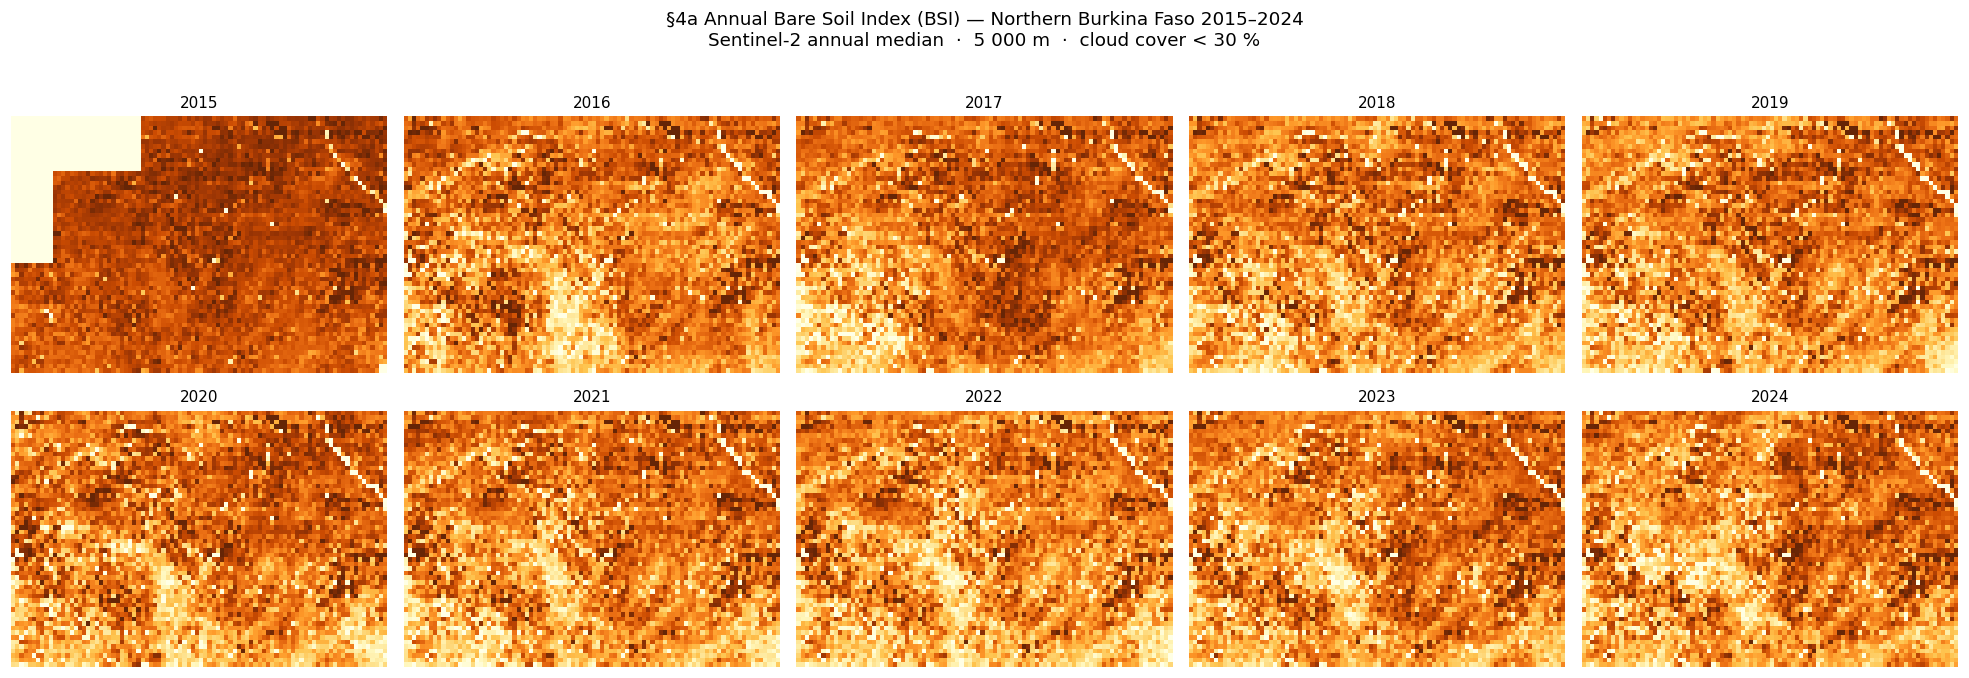

In [20]:
# Annual BSI — 2 rows × 5 columns
fig, axes = plt.subplots(2, 5, figsize=(18, 6))
for ax, yr in zip(axes.flat, s2_years):
    s2_ds[f"bsi_{yr}"].plot(ax=ax, cmap="YlOrBr", robust=True, add_colorbar=False)
    ax.set_title(str(yr), fontsize=10)
    ax.axis("off")
plt.suptitle(
    "§4a Annual Bare Soil Index (BSI) — Northern Burkina Faso 2015–2024\n"
    "Sentinel-2 annual median  ·  5 000 m  ·  cloud cover < 30 %",
    fontsize=12,
    y=1.02,
)
plt.savefig("../experiments/outputs/rl_annual_baresoil_index.png", dpi=150)
plt.tight_layout()
plt.show()

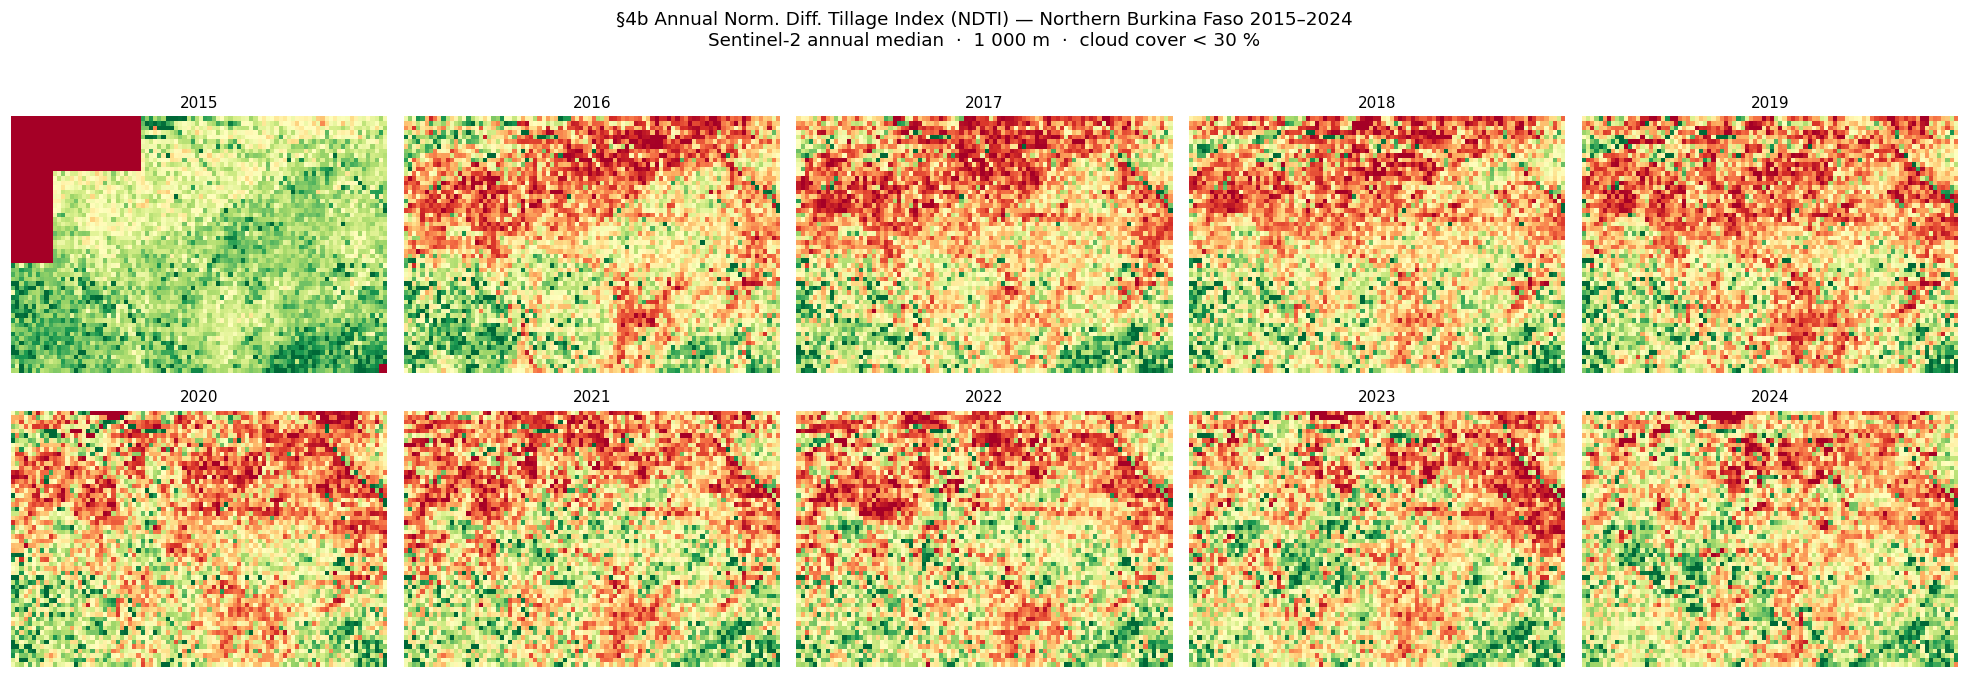

In [21]:
# Annual NDTI — 2 rows × 5 columns
fig, axes = plt.subplots(2, 5, figsize=(18, 6))
for ax, yr in zip(axes.flat, s2_years):
    s2_ds[f"ndti_{yr}"].plot(ax=ax, cmap="RdYlGn", robust=True, add_colorbar=False)
    ax.set_title(str(yr), fontsize=10)
    ax.axis("off")
plt.suptitle(
    "§4b Annual Norm. Diff. Tillage Index (NDTI) — Northern Burkina Faso 2015–2024\n"
    "Sentinel-2 annual median  ·  1 000 m  ·  cloud cover < 30 %",
    fontsize=12,
    y=1.02,
)
plt.tight_layout()
plt.savefig("../experiments/outputs/rl_annual_ndti.png", dpi=150)
plt.show()

---
## §5 — SRTM Terrain Slope

Source: **USGS SRTM 30 m** (`USGS/SRTMGL1_003`), resampled to 1 000 m.
Slope quantifies erosion susceptibility — steeper land loses topsoil faster under rainfall.

In [22]:
dem = ee.Image("USGS/SRTMGL1_003")
slope_img = ee.Terrain.slope(dem).clip(aoi).rename("slope_terrain")

url = slope_img.getDownloadURL(
    {"region": aoi, "scale": SCALE, "crs": "EPSG:4326", "format": "GEO_TIFF"}
)
response = requests.get(url)
response.raise_for_status()
slope_raw = rxr.open_rasterio(io.BytesIO(response.content)).squeeze()
slope_ds = xr.Dataset({"slope_terrain": slope_raw.rename({"x": "lon", "y": "lat"})})

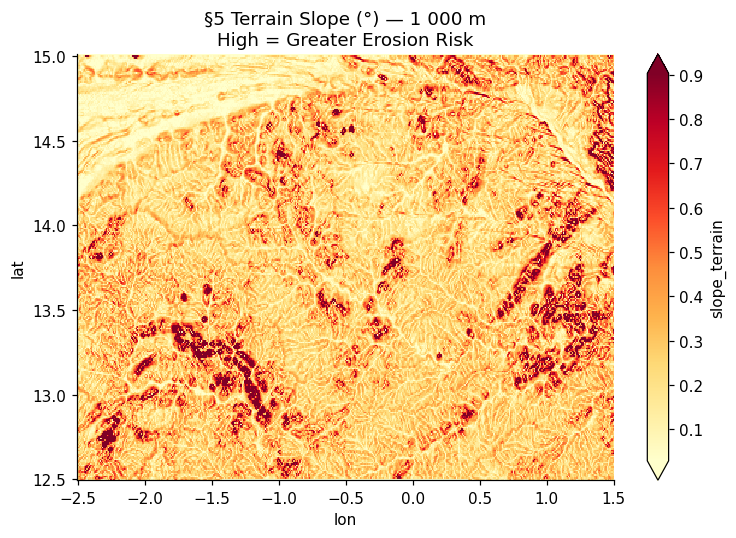

Slope range: [0.0°, 7.7°]


In [23]:
fig, ax = plt.subplots(figsize=(7, 5))
slope_ds["slope_terrain"].plot(ax=ax, cmap="YlOrRd", robust=True)
ax.set_title("§5 Terrain Slope (°) — 1 000 m\nHigh = Greater Erosion Risk")
plt.tight_layout()
plt.savefig("../experiments/outputs/rl_terrain.png", dpi=150)
plt.show()

print(
    f"Slope range: [{float(slope_ds['slope_terrain'].min()):.1f}°, {float(slope_ds['slope_terrain'].max()):.1f}°]"
)

---
## §6 — CHIRPS Rainfall Anomaly

Source: **CHIRPS daily** (`UCSB-CHG/CHIRPS/DAILY`), resampled to 1 000 m.
Pixel-wise linear trend in precipitation (2015–2024) via `linearFit` — expressed as mm yr⁻¹.
A negative slope means a drying trend, which amplifies vegetation degradation.

In [24]:
chirps = (
    ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY")
    .filterBounds(aoi)
    .filterDate(START, END)
    .select("precipitation")
)

In [25]:
def _add_t(img):
    t = img.date().difference(ee.Date(START), "year")
    return img.addBands(ee.Image(t).rename("time").float())


rain_anom = (
    chirps.map(_add_t)
    .select(["time", "precipitation"])
    .reduce(ee.Reducer.linearFit())
    .select("scale")
    .rename("rainfall_anom")
    .clip(aoi)
)

In [26]:
url = rain_anom.getDownloadURL(
    {"region": aoi, "scale": SCALE, "crs": "EPSG:4326", "format": "GEO_TIFF"}
)
response = requests.get(url)
response.raise_for_status()
rain_raw = rxr.open_rasterio(io.BytesIO(response.content)).squeeze()
rain_ds = xr.Dataset({"rainfall_anom": rain_raw.rename({"x": "lon", "y": "lat"})})

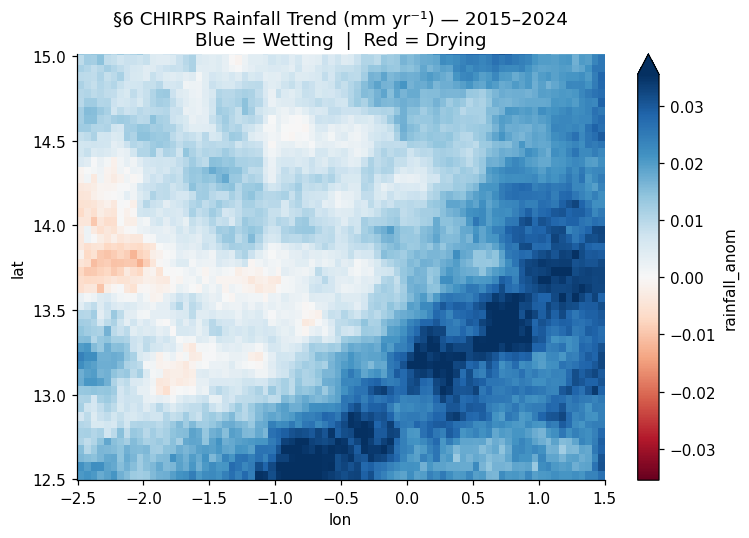

In [27]:
fig, ax = plt.subplots(figsize=(7, 5))
rain_ds["rainfall_anom"].plot(ax=ax, cmap="RdBu", robust=True)
ax.set_title(
    "§6 CHIRPS Rainfall Trend (mm yr⁻¹) — 2015–2024\nBlue = Wetting  |  Red = Drying"
)
plt.tight_layout()
plt.savefig("../experiments/outputs/rl_precipitation.png", dpi=150)
plt.show()

---
## §7 — ESA WorldCover 2021 — Land Cover

Source: **ESA WorldCover v200** (`ESA/WorldCover/v200`).
Dominant Sahelian classes: 30 (Grassland), 40 (Cropland), 60 (Bare/Sparse).
Class 60 indicates already-degraded ground.

In [28]:
worldcover = ee.ImageCollection("ESA/WorldCover/v200").first().select("Map").clip(aoi)
lc_norm = worldcover.divide(10).subtract(1).rename("land_cover")

In [29]:
url = worldcover.getDownloadURL(
    {"region": aoi, "scale": 100, "crs": "EPSG:4326", "format": "GEO_TIFF"}
)
response = requests.get(url)
response.raise_for_status()
lc_raw = rxr.open_rasterio(io.BytesIO(response.content)).squeeze()
lc_ds = xr.Dataset({"Map": lc_raw.rename({"x": "lon", "y": "lat"})})

In [30]:
LC_LABELS = {
    10: "Tree cover",
    20: "Shrubland",
    30: "Grassland",
    40: "Cropland",
    50: "Built-up",
    60: "Bare/Sparse",
    80: "Open water",
    90: "Wetland",
}
lc_vals = lc_ds["Map"].values.flatten()
lc_vals = lc_vals[~np.isnan(lc_vals)]
unique, counts = np.unique(lc_vals.astype(int), return_counts=True)
labels = [LC_LABELS.get(v, f"Class {v}") for v in unique]
pcts = counts / counts.sum() * 100

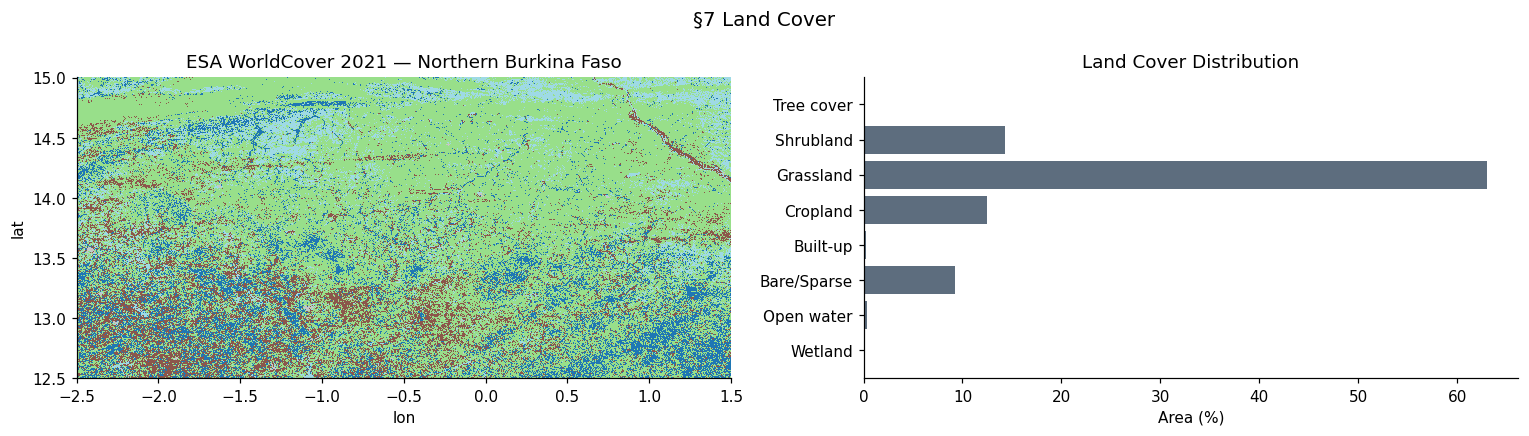

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
lc_ds["Map"].plot(ax=axes[0], cmap="tab20", robust=True, add_colorbar=False)
axes[0].set_title("ESA WorldCover 2021 — Northern Burkina Faso")
axes[1].barh(labels[::-1], pcts[::-1], color="#5D6D7E")
axes[1].set_xlabel("Area (%)")
axes[1].set_title("Land Cover Distribution")
plt.suptitle("§7 Land Cover", fontsize=13)
plt.tight_layout()
plt.savefig("../experiments/outputs/rl_landcover.png", dpi=150)
plt.show()

---
## §8 — Feature Stack & Point Sampling

All 8 bands stacked into a single GEE image and sampled at **1 000 m** → pandas DataFrame.

In [32]:
ndvi_feat = (
    trend_img.select("scale")
    .rename("ndvi_slope")
    .addBands(modis.mean().rename("ndvi_mean"))
    .addBands(
        modis.reduce(ee.Reducer.stdDev())
        .divide(modis.mean().abs().add(1e-6))
        .rename("ndvi_cv")
    )
)

In [33]:
feature_stack = (
    ndvi_feat.addBands(bsi_img.reproject("EPSG:4326", None, SCALE))
    .addBands(ndti_img.reproject("EPSG:4326", None, SCALE))
    .addBands(
        ee.Terrain.slope(dem)
        .clip(aoi)
        .reproject("EPSG:4326", None, SCALE)
        .rename("slope_terrain")
    )
    .addBands(rain_anom.reproject("EPSG:4326", None, SCALE))
    .addBands(lc_norm.reproject("EPSG:4326", None, SCALE))
)

In [34]:
print(f"Feature stack: {len(FEATURE_COLS)} bands @ {SCALE} m")

Feature stack: 8 bands @ 1000 m


In [35]:
for i, col in enumerate(FEATURE_COLS, 1):
    print(f"  {i:2d}. {col}")

sample = feature_stack.sample(
    region=aoi,
    scale=SCALE,
    numPixels=N_PIXELS,
    seed=42,
    dropNulls=True,
    geometries=False,
)
records = sample.getInfo()["features"]
df = pd.DataFrame([f["properties"] for f in records]).dropna()
df = df[FEATURE_COLS]

print(f"\nSampled: {len(df):,} pixels")
df.describe().round(4)

   1. ndvi_slope
   2. ndvi_mean
   3. ndvi_cv
   4. bsi
   5. ndti
   6. slope_terrain
   7. rainfall_anom
   8. land_cover

Sampled: 2,994 pixels


,ndvi_slope,ndvi_mean,ndvi_cv,bsi,ndti,slope_terrain,rainfall_anom,land_cover
count,2994.0000,2994.0000,2994.0000,2994.0000,2994.0000,2994.0000,2994.0000,2994.0000
mean,0.0057,0.2429,0.3910,0.2261,0.1230,0.2919,0.0148,2.2565
std,0.0039,0.0584,0.2453,0.0327,0.0237,0.2153,0.0104,1.0110
min,-0.0146,-0.0956,0.1043,-0.1235,0.0668,0.0000,-0.0121,1.0000
25%,0.0030,0.2051,0.3456,0.2113,0.1062,0.1662,0.0067,2.0000
50%,0.0051,0.2429,0.3928,0.2301,0.1203,0.2546,0.0133,2.0000
75%,0.0080,0.2812,0.4323,0.2441,0.1363,0.3592,0.0229,2.0000
max,0.0214,0.4873,12.4091,0.3549,0.2336,2.6069,0.0415,8.0000


---
## §9 — NDVI Annual Trend Analysis

Annual NDVI removes seasonal cycles — one value per year gives the clearest signal of
multi-year vegetation productivity change.

| Method | Assumption |
|--------|-----------|
| **OLS linear regression** | Constant linear trend |
| **Mann-Kendall** | Monotonic (non-parametric, robust to outliers) |

A rolling 3-year sub-trend reveals whether the rate is accelerating or reversing.

In [36]:
years = ndvi_annual.index.values.astype(float)
vals = ndvi_annual.values

res_ols = stats.linregress(years, vals)
slope_ols, intercept_ols = res_ols.slope, res_ols.intercept
r2_ols, p_ols = res_ols.rvalue**2, res_ols.pvalue

In [37]:
sig_ols = "SIGNIFICANT" if p_ols < 0.05 else "not significant"
print("=== OLS Linear Trend (annual) ===")
print(f"  Slope  : {slope_ols:+.5f} NDVI/year")
print(f"  R²     : {r2_ols:.4f}")
print(f"  p-value: {p_ols:.3e}  →  {sig_ols} at α=0.05")

=== OLS Linear Trend (annual) ===
  Slope  : +0.00425 NDVI/year
  R²     : 0.7948
  p-value: 5.310e-04  →  SIGNIFICANT at α=0.05


In [38]:
mk_tau, mk_p = stats.kendalltau(years, vals)
mk_dir = "decreasing" if mk_tau < 0 else "increasing"
sig_mk = "SIGNIFICANT" if mk_p < 0.05 else "not significant"
print()
print("=== Mann-Kendall Test (annual) ===")
print(f"  τ      : {mk_tau:+.4f}  ({mk_dir})")
print(f"  p-value: {mk_p:.3e}  →  {sig_mk} at α=0.05")


=== Mann-Kendall Test (annual) ===
  τ      : +0.6889  (increasing)
  p-value: 4.687e-03  →  SIGNIFICANT at α=0.05


In [39]:
# Rolling 3-year sub-trends on annual data
window = 3
rolling_slopes, rolling_years = [], []
for i in range(len(ndvi_annual) - window + 1):
    sub = ndvi_annual.iloc[i : i + window]
    rolling_slopes.append(
        stats.linregress(sub.index.values.astype(float), sub.values).slope
    )
    rolling_years.append(sub.index[window // 2])

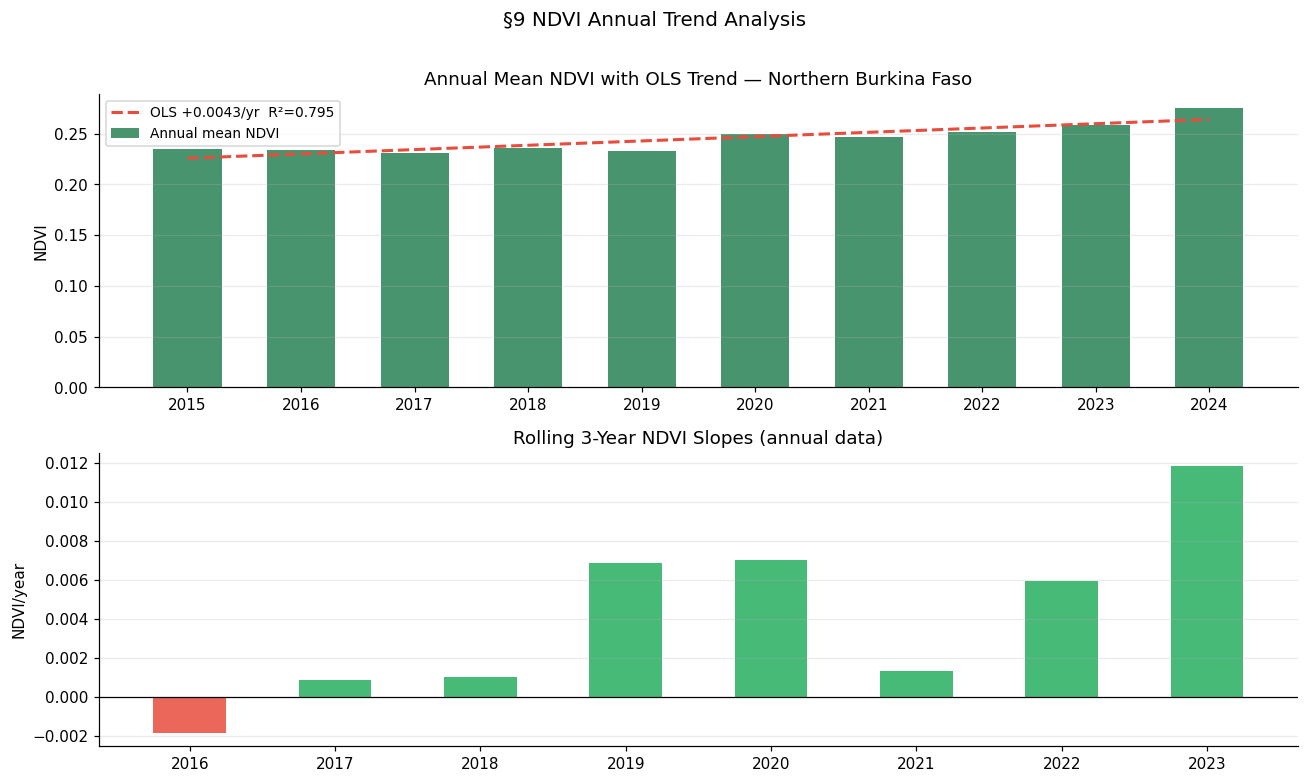

In [40]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7))

ax = axes[0]
ax.bar(
    ndvi_annual.index,
    ndvi_annual.values,
    color="#1A7A4A",
    width=0.6,
    alpha=0.8,
    label="Annual mean NDVI",
)
trend_y = intercept_ols + slope_ols * years
ax.plot(
    ndvi_annual.index,
    trend_y,
    "--",
    color="#E74C3C",
    lw=2,
    label=f"OLS {slope_ols:+.4f}/yr  R²={r2_ols:.3f}",
)
ax.set_ylabel("NDVI")
ax.set_title("Annual Mean NDVI with OLS Trend — Northern Burkina Faso")
ax.set_xticks(ndvi_annual.index)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.25)

ax = axes[1]
c_roll = ["#E74C3C" if s < 0 else "#27AE60" for s in rolling_slopes]
ax.bar(rolling_years, rolling_slopes, color=c_roll, width=0.5, alpha=0.85)
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("NDVI/year")
ax.set_title("Rolling 3-Year NDVI Slopes (annual data)")
ax.set_xticks(rolling_years)
ax.grid(axis="y", alpha=0.25)

plt.suptitle("§9 NDVI Annual Trend Analysis", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("../experiments/outputs/rl_ndvi_ols_trend.png", dpi=150)
plt.show()

---
## §10 — Structural Breakpoint Detection (Annual Series)

**Binseg RBF** on the 10-point annual NDVI series.
`jump=1` is set explicitly — with only 10 observations, every year must be a candidate
breakpoint (the default `jump=5` would leave too few candidates).

In [41]:
signal_vals = ndvi_annual.dropna().values
n_obs = len(signal_vals)
signal = signal_vals.reshape(-1, 1)

min_size = 1  # minimum 1 year per segment
jump = 1  # every year is a candidate (annual data)

# Use ruptures' own sanity_check to find the largest feasible n_bkps
n_bkps = next(
    (k for k in range(3, 0, -1) if sanity_check(n_obs, k, jump, min_size)),
    1,
)
print(f"Signal: {n_obs} annual obs  |  min_size={min_size}  |  n_bkps={n_bkps}")

Signal: 10 annual obs  |  min_size=1  |  n_bkps=3


In [42]:
ts_clean = ndvi_annual.dropna()
binseg = rpt.Binseg(model="rbf", min_size=min_size, jump=jump).fit(signal)
bkps_raw = binseg.predict(n_bkps=n_bkps)
breakpoints = bkps_raw[:-1]

bkp_years = [ts_clean.index[i - 1] for i in breakpoints]
print(f"Detected {len(breakpoints)} breakpoint(s): {bkp_years}")

max_k = min(n_bkps + 2, n_obs - min_size)
cost_fn = rpt.costs.CostRbf().fit(signal)
costs = [cost_fn.sum_of_costs(binseg.predict(n_bkps=k)) for k in range(1, max_k + 1)]

Detected 3 breakpoint(s): [2019, 2022, 2023]


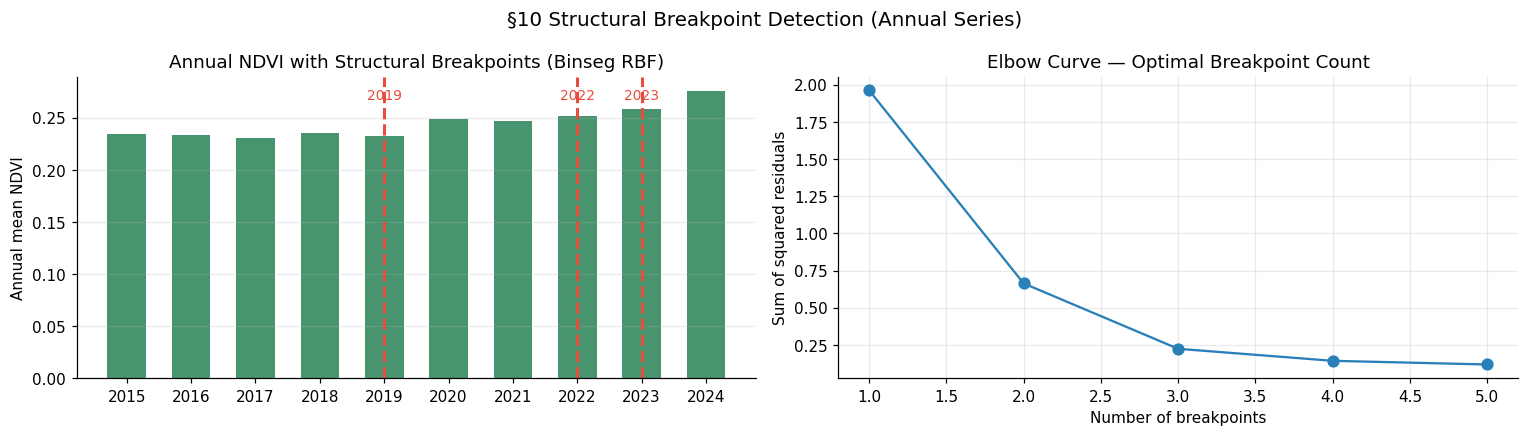

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.bar(ts_clean.index, ts_clean.values, color="#1A7A4A", width=0.6, alpha=0.8)
for yr in bkp_years:
    ax.axvline(yr, color="#E74C3C", ls="--", lw=2)
    ax.annotate(
        str(yr),
        xy=(yr, ts_clean.max() * 0.97),
        fontsize=9,
        color="#E74C3C",
        ha="center",
    )
ax.set_ylabel("Annual mean NDVI")
ax.set_title("Annual NDVI with Structural Breakpoints (Binseg RBF)")
ax.set_xticks(ts_clean.index)
ax.grid(axis="y", alpha=0.25)

axes[1].plot(range(1, max_k + 1), costs, "o-", color="#2980B9", ms=7)
axes[1].set_xlabel("Number of breakpoints")
axes[1].set_ylabel("Sum of squared residuals")
axes[1].set_title("Elbow Curve — Optimal Breakpoint Count")
axes[1].grid(alpha=0.25)

plt.suptitle("§10 Structural Breakpoint Detection (Annual Series)", fontsize=13)
plt.tight_layout()
plt.savefig("../experiments/outputs/rl_structural_breakpoint.png", dpi=150)
plt.show()

In [44]:
breakpoint_year = int(bkp_years[0]) if bkp_years else None
print(f"Primary breakpoint year: {breakpoint_year}")

Primary breakpoint year: 2019


---
## §11 — Degradation Scoring & Labelling

Composite score (0–100) from six feature sub-scores.  
The binary threshold is **data-driven**: the **70th percentile** of the score distribution,
so the top 30 % of pixels are always labelled **Degraded** — robust to score range shifts.

| Weight | Feature | Direction |
|--------|---------|----------|
| 35 % | `ndvi_slope` | More negative → higher score |
| 20 % | `bsi` | Higher bare soil → higher score |
| 15 % | `ndti` | Lower residue → higher score |
| 12 % | `rainfall_anom` | Drying trend → higher score |
| 10 % | `slope_terrain` | Steeper terrain → higher score |
| 8 % | `ndvi_cv` | Higher instability → higher score |

In [45]:
def _minmax(arr, lo, hi):
    return np.clip((arr - lo) / (hi - lo + 1e-8) * 100, 0, 100)


scores = pd.DataFrame(index=df.index)
scores["s_ndvi_slope"] = _minmax(-df["ndvi_slope"], -0.03, 0.03)
scores["s_bsi"] = _minmax(df["bsi"], -0.40, 0.60)
scores["s_ndti"] = _minmax(-df["ndti"], -0.50, 0.30)
scores["s_rainfall_anom"] = _minmax(-df["rainfall_anom"], -0.50, 0.50)
scores["s_slope_terrain"] = _minmax(df["slope_terrain"], 0.00, 20.00)
scores["s_ndvi_cv"] = _minmax(df["ndvi_cv"], 0.00, 0.50)

WEIGHTS = {
    "s_ndvi_slope": 0.35,
    "s_bsi": 0.20,
    "s_ndti": 0.15,
    "s_rainfall_anom": 0.12,
    "s_slope_terrain": 0.10,
    "s_ndvi_cv": 0.08,
}
deg_score = sum(scores[c] * w for c, w in WEIGHTS.items())

In [46]:
# Data-driven threshold: top 30 % of pixels by score → Degraded
DEGRADATION_THRESHOLDS[0] = float(np.percentile(deg_score, 70))
print(f"Score range  : [{deg_score.min():.1f}, {deg_score.max():.1f}]")
print(
    f"Threshold    : {DEGRADATION_THRESHOLDS[0]:.1f}  (70th percentile — top 30 % = Degraded)"
)


def _classify(s):
    return 0 if s < DEGRADATION_THRESHOLDS[0] else 1


features_df = df.copy()
features_df["deg_score"] = deg_score.values
features_df["deg_class"] = deg_score.apply(_classify).astype(int).values
features_df["deg_label"] = features_df["deg_class"].map(
    dict(enumerate(DEGRADATION_CLASSES))
)

class_dist = features_df["deg_label"].value_counts(normalize=True).mul(100)
print("\nClass distribution:")

Score range  : [34.4, 59.5]
Threshold    : 47.1  (70th percentile — top 30 % = Degraded)

Class distribution:


In [47]:
for cls in DEGRADATION_CLASSES:
    pct = class_dist.get(cls, 0)
    print(f"  {cls:<20}  {pct:5.1f}%  " + "#" * int(pct / 2))

  Not Degraded           70.0%  ###################################
  Degraded               30.0%  ##############


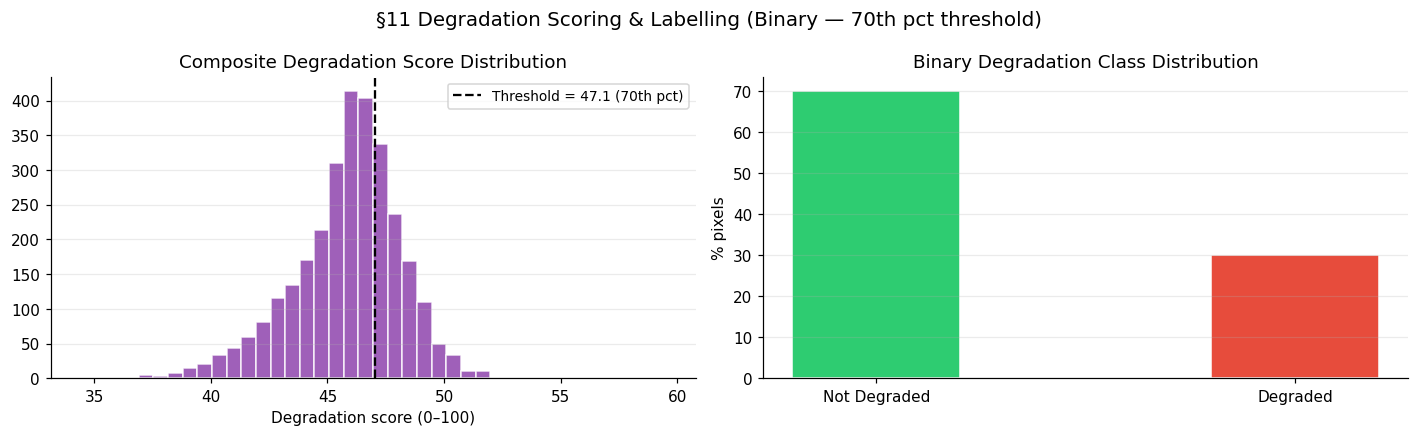

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(deg_score, bins=40, color="#8E44AD", edgecolor="white", alpha=0.85)
axes[0].axvline(
    DEGRADATION_THRESHOLDS[0],
    color="black",
    ls="--",
    lw=1.5,
    label=f"Threshold = {DEGRADATION_THRESHOLDS[0]:.1f} (70th pct)",
)
axes[0].set_xlabel("Degradation score (0–100)")
axes[0].set_title("Composite Degradation Score Distribution")
axes[0].legend(fontsize=9)
axes[0].grid(axis="y", alpha=0.25)

pcts = [class_dist.get(c, 0) for c in DEGRADATION_CLASSES]
axes[1].bar(
    DEGRADATION_CLASSES, pcts, color=DEGRADATION_COLORS, edgecolor="white", width=0.4
)
axes[1].set_ylabel("% pixels")
axes[1].set_title("Binary Degradation Class Distribution")
axes[1].grid(axis="y", alpha=0.25)

plt.suptitle(
    "§11 Degradation Scoring & Labelling (Binary — 70th pct threshold)", fontsize=13
)
plt.tight_layout()
plt.savefig("../experiments/outputs/rl_scoring_and_labelling.png", dpi=150)
plt.show()

---
## §12 — Feature EDA

In [49]:
df_feat = features_df[FEATURE_COLS].copy()
print(f"Feature matrix: {df_feat.shape[0]:,} pixels  ×  {df_feat.shape[1]} features\n")
display(df_feat.describe().round(4))

Feature matrix: 2,994 pixels  ×  8 features



,ndvi_slope,ndvi_mean,ndvi_cv,bsi,ndti,slope_terrain,rainfall_anom,land_cover
count,2994.0000,2994.0000,2994.0000,2994.0000,2994.0000,2994.0000,2994.0000,2994.0000
mean,0.0057,0.2429,0.3910,0.2261,0.1230,0.2919,0.0148,2.2565
std,0.0039,0.0584,0.2453,0.0327,0.0237,0.2153,0.0104,1.0110
min,-0.0146,-0.0956,0.1043,-0.1235,0.0668,0.0000,-0.0121,1.0000
25%,0.0030,0.2051,0.3456,0.2113,0.1062,0.1662,0.0067,2.0000
50%,0.0051,0.2429,0.3928,0.2301,0.1203,0.2546,0.0133,2.0000
75%,0.0080,0.2812,0.4323,0.2441,0.1363,0.3592,0.0229,2.0000
max,0.0214,0.4873,12.4091,0.3549,0.2336,2.6069,0.0415,8.0000


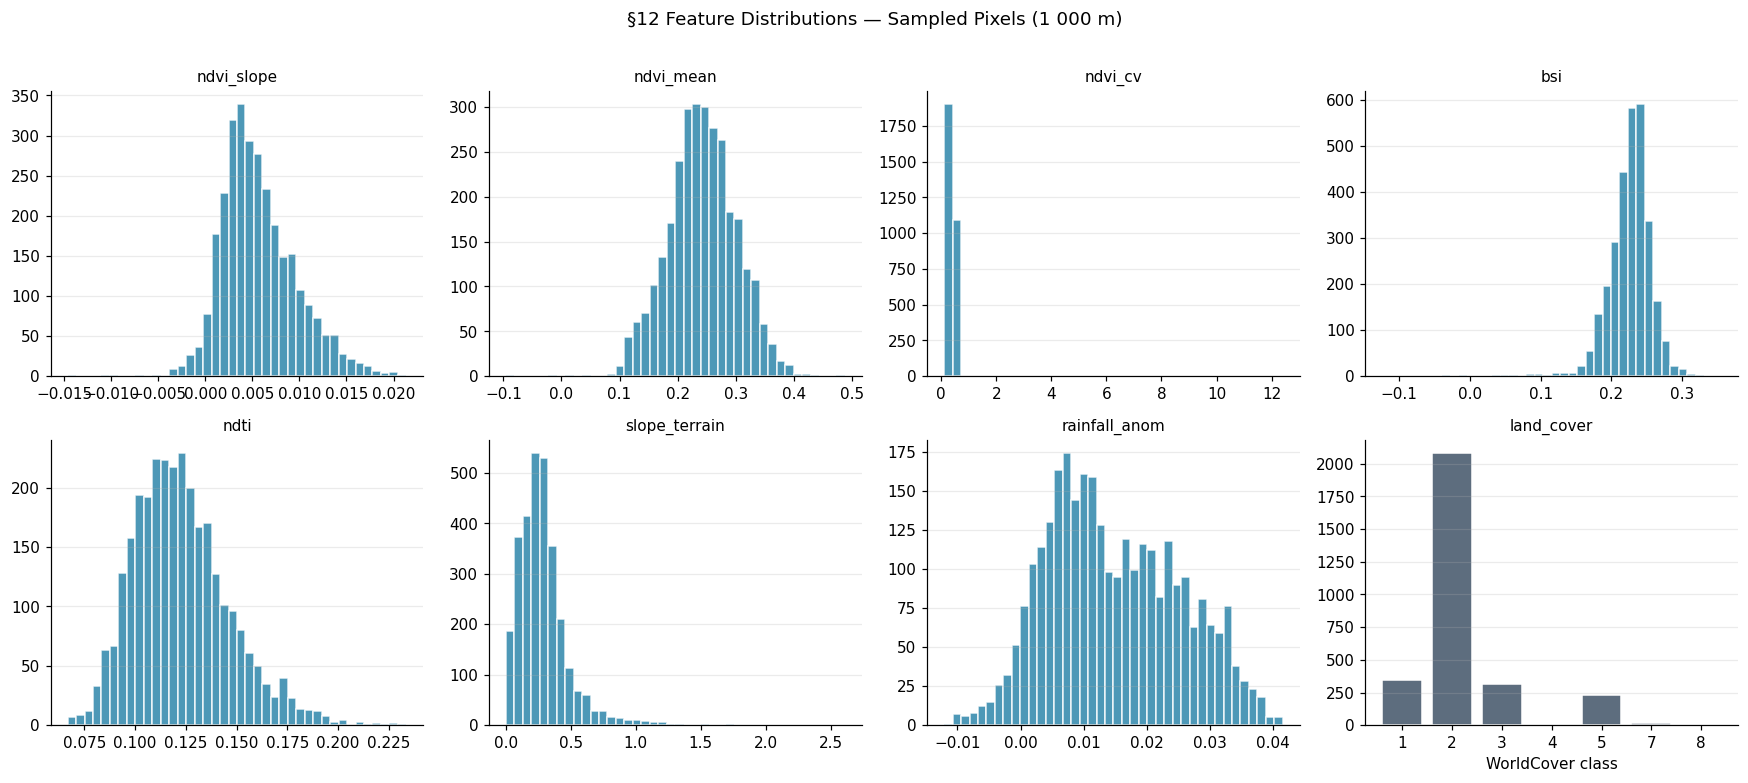

In [50]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for i, col in enumerate(FEATURE_COLS):
    ax = axes.flat[i]
    data = df_feat[col].dropna()
    if col == "land_cover":
        vals, cnts = np.unique(data.astype(int), return_counts=True)
        ax.bar(vals.astype(str), cnts, color="#5D6D7E", edgecolor="white")
        ax.set_xlabel("WorldCover class")
    else:
        ax.hist(data, bins=40, color="#2E86AB", edgecolor="white", alpha=0.85)
    ax.set_title(col, fontsize=10)
    ax.grid(axis="y", alpha=0.25)
plt.suptitle(
    "§12 Feature Distributions — Sampled Pixels (1 000 m)", fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig("../experiments/outputs/rl_feature_distribution.png", dpi=150)
plt.show()

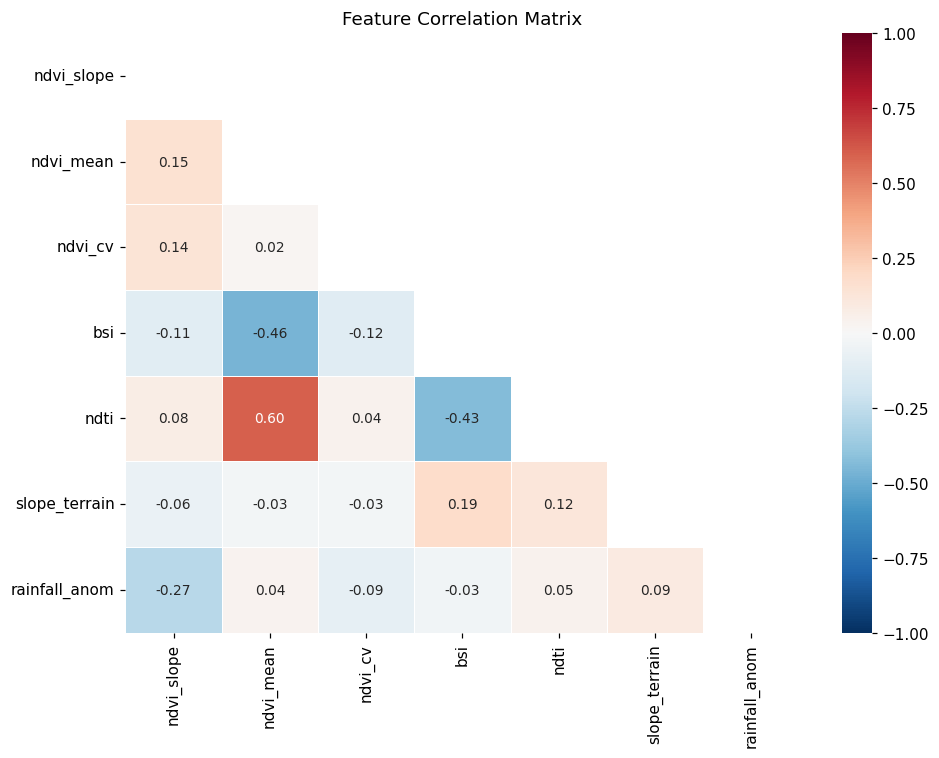

In [51]:
numeric_cols = [c for c in FEATURE_COLS if c != "land_cover"]
corr = df_feat[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.5,
    ax=ax,
    vmin=-1,
    vmax=1,
    annot_kws={"fontsize": 9},
)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.savefig("../experiments/outputs/rl_feature_correlation_matrix.png", dpi=150)
plt.show()

In [52]:
print("Correlations with ndvi_slope:")
for feat, r in (
    corr["ndvi_slope"].drop("ndvi_slope").sort_values(key=abs, ascending=False).items()
):
    print(f"  {feat:<22}  r = {r:+.3f}  " + "|" * int(abs(r) * 20))

Correlations with ndvi_slope:
  rainfall_anom           r = -0.274  |||||
  ndvi_mean               r = +0.153  |||
  ndvi_cv                 r = +0.137  ||
  bsi                     r = -0.114  ||
  ndti                    r = +0.077  |
  slope_terrain           r = -0.065  |


---
## §13 — Random Forest Classifier

80/20 stratified split + 5-fold CV. `class_weight='balanced'` for unequal class counts.

In [53]:
X = features_df[FEATURE_COLS].fillna(features_df[FEATURE_COLS].median())
y = features_df["deg_class"].astype(int)

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

In [55]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=4,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train_s, y_train)
y_pred_rf = rf.predict(X_test_s)
acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf, average="weighted")

In [56]:
print("=== Random Forest ===")
print(f"  Test accuracy : {acc_rf:.4f}")
print(f"  Test F1 (wtd) : {f1_rf:.4f}")
print()
print(classification_report(y_test, y_pred_rf, target_names=DEGRADATION_CLASSES))

=== Random Forest ===
  Test accuracy : 0.9366
  Test F1 (wtd) : 0.9362

              precision    recall  f1-score   support

Not Degraded       0.95      0.96      0.95       419
    Degraded       0.91      0.88      0.89       180

    accuracy                           0.94       599
   macro avg       0.93      0.92      0.92       599
weighted avg       0.94      0.94      0.94       599



  CV F1 (5-fold): 0.9463  ±  0.0087


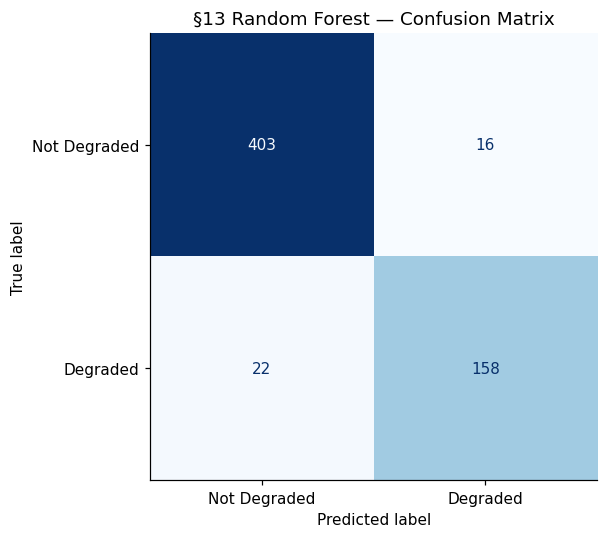

In [57]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# n_jobs=1: RF already uses n_jobs=-1 internally; outer process forks cause oversubscription
cv_rf = cross_val_score(
    rf, scaler.transform(X), y, cv=cv, scoring="f1_weighted", n_jobs=1
)
print(f"  CV F1 (5-fold): {cv_rf.mean():.4f}  ±  {cv_rf.std():.4f}")

fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=DEGRADATION_CLASSES,
    cmap="Blues",
    ax=ax,
    colorbar=False,
)
ax.set_title("§13 Random Forest — Confusion Matrix")
plt.tight_layout()
plt.savefig("../experiments/outputs/rl_rf_confusion_matrix.png", dpi=150)
plt.show()

---
## §14 — LightGBM Classifier

In [58]:
lgb_clf = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=63,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
)
lgb_clf.fit(X_train_s, y_train)
y_pred_lgb = lgb_clf.predict(X_test_s)
acc_lgb = accuracy_score(y_test, y_pred_lgb)
f1_lgb = f1_score(y_test, y_pred_lgb, average="weighted")

# n_jobs=1: LightGBM uses OpenMP threads internally (n_jobs=-1 above).
# Forking 5 CV processes on top causes 5× CPU oversubscription and ResourceTracker errors.
cv_lgb = cross_val_score(
    lgb_clf, scaler.transform(X), y, cv=cv, scoring="f1_weighted", n_jobs=1
)

In [59]:
print("=== LightGBM ===")
print(f"  Test accuracy : {acc_lgb:.4f}")
print(f"  Test F1 (wtd) : {f1_lgb:.4f}")
print(f"  CV F1 (5-fold): {cv_lgb.mean():.4f}  ±  {cv_lgb.std():.4f}")

=== LightGBM ===
  Test accuracy : 0.9649
  Test F1 (wtd) : 0.9647
  CV F1 (5-fold): 0.9626  ±  0.0068


In [60]:
comp_df = pd.DataFrame(
    {
        "Model": ["Random Forest", "LightGBM"],
        "Test Acc": [round(acc_rf, 4), round(acc_lgb, 4)],
        "Test F1": [round(f1_rf, 4), round(f1_lgb, 4)],
        "CV F1 mean": [round(cv_rf.mean(), 4), round(cv_lgb.mean(), 4)],
        "CV F1 std": [round(cv_rf.std(), 4), round(cv_lgb.std(), 4)],
    }
)
display(comp_df.set_index("Model"))

,Test Acc,Test F1,CV F1 mean,CV F1 std
Model,,,,
Random Forest,0.9366,0.9362,0.9463,0.0087
LightGBM,0.9649,0.9647,0.9626,0.0068


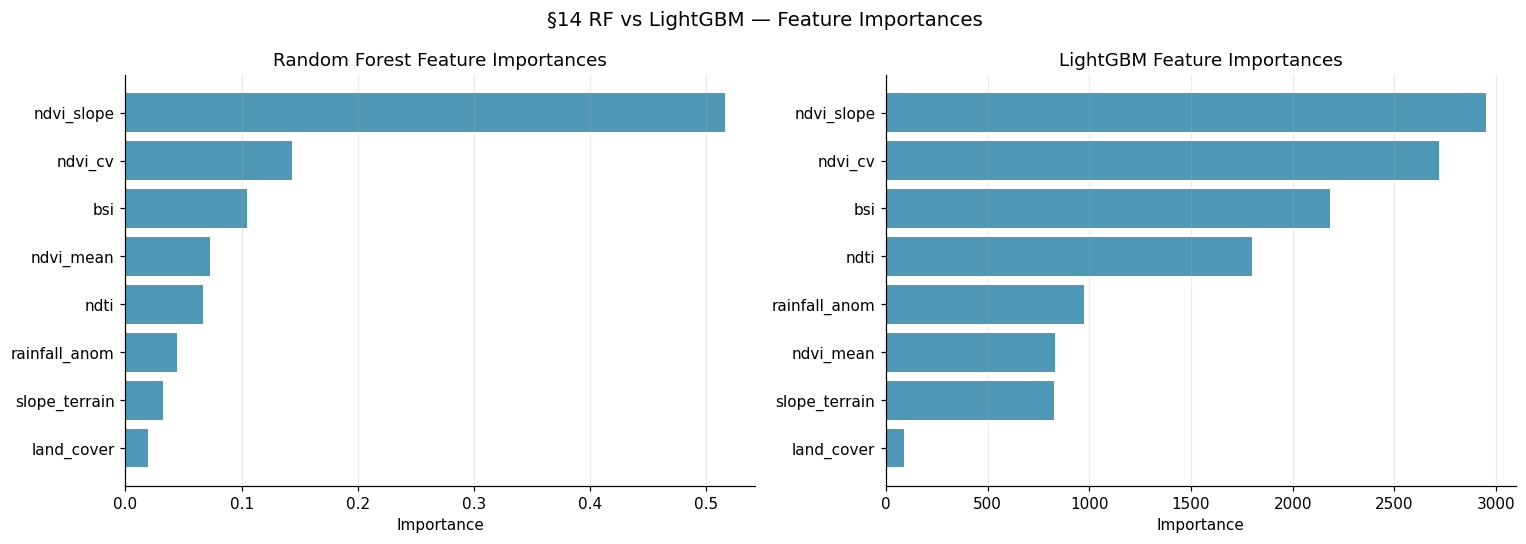

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, model, name in [(axes[0], rf, "Random Forest"), (axes[1], lgb_clf, "LightGBM")]:
    imps = model.feature_importances_
    order = np.argsort(imps)
    ax.barh([FEATURE_COLS[i] for i in order], imps[order], color="#2E86AB", alpha=0.85)
    ax.set_title(f"{name} Feature Importances")
    ax.set_xlabel("Importance")
    ax.grid(axis="x", alpha=0.25)
plt.suptitle("§14 RF vs LightGBM — Feature Importances", fontsize=13)
plt.tight_layout()
plt.savefig("../experiments/outputs/rl_lightGBM_feature_importance.png", dpi=150)
plt.show()

In [62]:
print(
    f"Best baseline: {'Random Forest' if f1_rf >= f1_lgb else 'LightGBM'}  "
    f"(F1={max(f1_rf, f1_lgb):.4f})"
)

Best baseline: LightGBM  (F1=0.9647)


---
## §15 — Hyperparameter Tuning (Optuna TPE, 20 trials)

In [63]:
def _objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 600, step=50),
        "max_depth": trial.suggest_int("max_depth", 3, 25),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 12),
        "max_features": trial.suggest_categorical(
            "max_features", ["sqrt", "log2", 0.5, 0.7]
        ),
        "class_weight": "balanced",
        "random_state": 42,
        "n_jobs": -1,
    }
    m = RandomForestClassifier(**params)
    return cross_val_score(
        m, X_train_s, y_train, cv=3, scoring="f1_weighted", n_jobs=-1
    ).mean()

In [64]:
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
)
study.optimize(_objective, n_trials=20, show_progress_bar=True)

  0%|          | 0/20 [00:00<?, ?it/s]

In [65]:
print()
print("=== Optuna Best Trial ===")
print(f"  Best CV F1 : {study.best_value:.4f}")
for k, v in study.best_params.items():
    print(f"  {k:<22}: {v}")


=== Optuna Best Trial ===
  Best CV F1 : 0.9445
  n_estimators          : 600
  max_depth             : 18
  min_samples_leaf      : 1
  max_features          : 0.5


In [66]:
rf_tuned = RandomForestClassifier(
    **study.best_params, class_weight="balanced", random_state=42, n_jobs=-1
)
rf_tuned.fit(X_train_s, y_train)
f1_tuned = f1_score(y_test, rf_tuned.predict(X_test_s), average="weighted")

In [67]:
print(f"\nTuned RF F1  : {f1_tuned:.4f}")
print(f"Default RF F1: {f1_rf:.4f}")
print(f"LightGBM F1  : {f1_lgb:.4f}")

final_model = rf_tuned if f1_tuned >= f1_lgb else lgb_clf
final_name = "RF (Optuna-tuned)" if f1_tuned >= f1_lgb else "LightGBM"
print(f"\nFinal model: {final_name}")


Tuned RF F1  : 0.9473
Default RF F1: 0.9362
LightGBM F1  : 0.9647

Final model: LightGBM


---
## §16 — SHAP Feature Importance

- **Beeswarm**: per-sample SHAP values for the Severely Degraded class
- **Bar**: mean |SHAP| across all four classes

In [68]:
X_test_df = pd.DataFrame(X_test_s, columns=FEATURE_COLS)
explainer = shap.TreeExplainer(final_model)
shap_vals = explainer.shap_values(X_test_df)

/home/oderogeorge/arin-dss/arin-climate/.venv/lib/python3.12/site-packages/shap/explainers/_tree.py:448: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn('LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray')


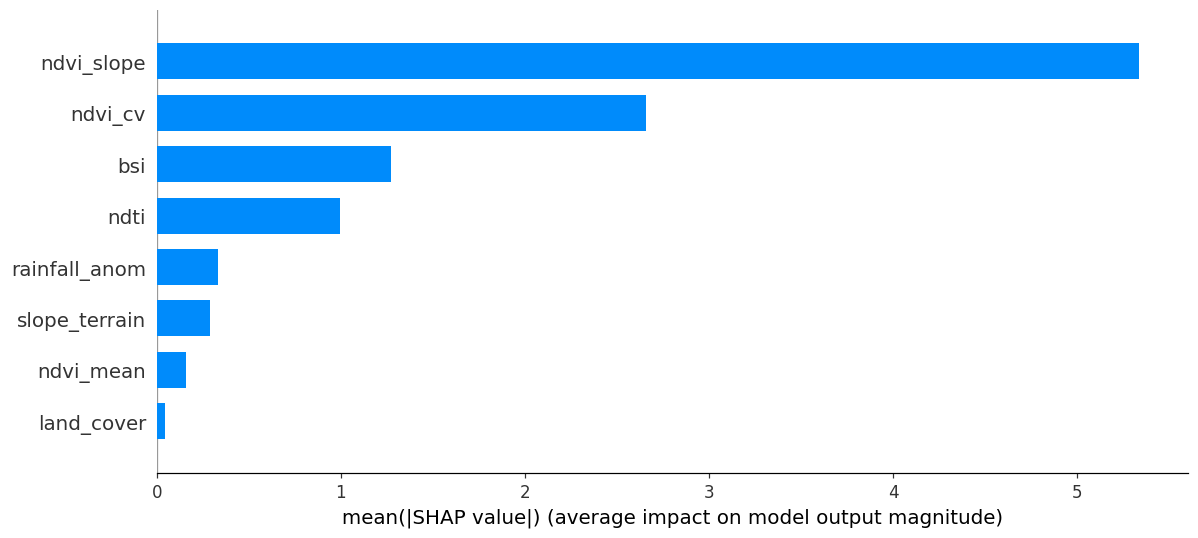

In [69]:
if isinstance(shap_vals, list):
    mean_abs_shap = np.array([np.abs(sv).mean(axis=0) for sv in shap_vals]).mean(axis=0)
    print("=== SHAP Mean |value| per feature (all classes avg) ===")
    for i in np.argsort(mean_abs_shap)[::-1]:
        print(f"  {FEATURE_COLS[i]:<22}  {mean_abs_shap[i]:.4f}")
    shap.summary_plot(
        shap_vals[3], X_test_df, plot_type="dot", show=False, plot_size=(11, 5)
    )
    plt.title("SHAP Values — Severely Degraded Class")
    plt.tight_layout()
    plt.show()
    shap.summary_plot(
        shap_vals,
        X_test_df,
        plot_type="bar",
        class_names=DEGRADATION_CLASSES,
        show=False,
        plot_size=(11, 5),
    )
    plt.title("§16 SHAP Mean |Value| — All Degradation Classes")
    plt.tight_layout()
    plt.show()
else:
    mean_abs_shap = np.abs(shap_vals).mean(axis=0)
    shap.summary_plot(
        shap_vals, X_test_df, plot_type="bar", show=False, plot_size=(11, 5)
    )
    plt.tight_layout()
    plt.show()

In [70]:
top_driver = FEATURE_COLS[int(np.argmax(mean_abs_shap))]
print(f"Top degradation driver: {top_driver}")

Top degradation driver: ndvi_slope


---
### §16 Feature Justification — Why Each Variable Was Selected

| Feature | Physical Role | Supporting Evidence |
|---------|--------------|-------------------|
| `ndvi_slope` | Rate of vegetation change (NDVI yr⁻¹) over 2015–2024 | Herrmann *et al.* (2005) and Wessels *et al.* (2007) established pixel-wise NDVI trend as the standard proxy for long-term land productivity decline in drylands. Negative slope = progressive vegetation loss independent of rainfall year. |
| `ndvi_cv` | Inter-annual vegetation instability (σ / μ across years) | Fensholt & Proud (2012) showed that high CV in Sahelian NDVI signals fragile rain-use efficiency — degraded land tracks rainfall linearly rather than maintaining a stable perennial canopy. High CV is a leading indicator of desertification risk. |
| `bsi` | Bare Soil Index — spectral exposure of mineral soil | Validated by Rikimaru *et al.* (2002) and widely used in UNCCD land degradation neutrality assessments. Combines SWIR1, Red, NIR, Blue to isolate bare-soil reflectance; insensitive to vegetation noise in dry-season composites. |
| `ndti` | Normalised Difference Tillage Index — surface organic litter | Devised by van Deventer *et al.* (1997). SWIR1/SWIR2 ratio distinguishes residue and organic litter from bare mineral soil, capturing protective ground cover that BSI misses. Low NDTI + high BSI together confirm physical degradation. |
| `slope_terrain` | Terrain steepness (°) from SRTM | FAO (2019) *Soil Erosion by Water* report identifies slope as the primary topographic control on rill and sheet erosion under sparse cover. In semi-arid West Africa, slopes > 2° significantly increase soil loss rates under seasonal rainfall. |
| `rainfall_anom` | CHIRPS precipitation trend (mm yr⁻¹) 2015–2024 | Distinguishes **climate-driven** greening/browning from **human-induced** degradation (Bai *et al.*, 2008; Wessels *et al.*, 2012). A pixel with negative NDVI slope but positive rainfall trend is more likely human-induced; the inverse may be drought stress only. |
| `ndvi_mean` | 10-year mean NDVI — baseline productivity | Provides absolute productivity context for the trend. A pixel with low mean NDVI and a declining slope is more severely degraded than one with high mean NDVI and the same slope. Core to the RESTREND framework (Evans & Geerken, 2004). |
| `land_cover` | ESA WorldCover 2021 dominant class | Land-use context — cropland (class 40) degrades under tillage differently from rangeland (class 30) under grazing. Near-zero SHAP here, but retained to prevent systematic bias when the model is applied across mixed land-use regions. |

---

**Key references**
- Bai *et al.* (2008). *Global Assessment of Land Degradation and Improvement.* ISRIC.
- Evans & Geerken (2004). *Discrimination between climate and human-induced dryland degradation.* Journal of Arid Environments.
- Fensholt & Proud (2012). *Evaluation of Earth Observation based global long term vegetation trends.* Remote Sensing of Environment.
- Herrmann *et al.* (2005). *Recent trends in vegetation dynamics in the African Sahel.* Global Environmental Change.
- Rikimaru *et al.* (2002). *Tropical forest cover density mapping.* Tropical Ecology.
- van Deventer *et al.* (1997). *Using Thematic Mapper data to identify contrasting soil plains and tillage practices.* Photogrammetric Engineering and Remote Sensing.
- Wessels *et al.* (2007 & 2012). *Limits to detectability of land degradation by trend analysis of NDVI.* Remote Sensing of Environment.

---
## §17 — Result Packaging

DSS payload matching `LandDegradationUseCase.run()` schema.

In [71]:
X_all = features_df[FEATURE_COLS].fillna(features_df[FEATURE_COLS].median())
y_all_pred = final_model.predict(scaler.transform(X_all))
cls_counts = pd.Series(y_all_pred).value_counts().sort_index()

pixel_ha = (SCALE**2) / 10_000
total_ha = round(len(y_all_pred) * pixel_ha, 1)

risk_pct, risk_ha = [], []
for cls_i in range(len(DEGRADATION_CLASSES)):
    cnt = int(cls_counts.get(cls_i, 0))
    risk_pct.append(round(cnt / len(y_all_pred) * 100, 1))
    risk_ha.append(round(cnt * pixel_ha, 1))

In [72]:
result = {
    "module": "land_degradation",
    "stats": {
        "study_area": "Northern Burkina Faso, Sahel (Bam & Soum provinces)",
        "model_type": final_name,
        "n_pixels": int(len(y_all_pred)),
        "total_area_ha": total_ha,
        "feature_scale_m": SCALE,
        "ndvi_aggregation": "annual mean (MODIS MOD13A3 monthly → resample YE)",
        "test_f1": round(
            float(f1_score(y_test, final_model.predict(X_test_s), average="weighted")),
            4,
        ),
        "test_accuracy": round(
            float(accuracy_score(y_test, final_model.predict(X_test_s))), 4
        ),
        "ndvi_trend_per_year": round(float(slope_ols), 5),
        "mk_tau": round(float(mk_tau), 4),
        "mk_significant": bool(mk_p < 0.05),
        "breakpoint_year": breakpoint_year,
        "not_degraded_pct": risk_pct[0],
        "degraded_pct": risk_pct[1],
        "not_degraded_ha": risk_ha[0],
        "degraded_ha": risk_ha[1],
        "top_driver": top_driver,
    },
    "riskDist": {
        "labels": DEGRADATION_CLASSES,
        "data": risk_pct,
        "data_ha": risk_ha,
        "colors": DEGRADATION_COLORS,
    },
    "timeSeries": {
        "labels": ndvi_annual.index.tolist(),
        "datasets": [
            {
                "label": "Annual NDVI",
                "data": ndvi_annual.round(4).tolist(),
                "color": "#27AE60",
            },
        ],
    },
    "shap": {
        "features": FEATURE_COLS,
        "mean_abs_shap": [round(float(v), 4) for v in mean_abs_shap],
    },
    "raster": {},
}

In [73]:
print("=" * 60)
print("FINAL RESULT SCHEMA")
print(json.dumps(result["stats"], indent=2))
print()
print("Risk Distribution:")
for i, cls in enumerate(DEGRADATION_CLASSES):
    print(
        f"  {cls:<20}  {result['riskDist']['data'][i]:5.1f}%  "
        f"({result['riskDist']['data_ha'][i]:,.0f} ha)"
    )

FINAL RESULT SCHEMA
{
  "study_area": "Northern Burkina Faso, Sahel (Bam & Soum provinces)",
  "model_type": "LightGBM",
  "n_pixels": 2994,
  "total_area_ha": 299400.0,
  "feature_scale_m": 1000,
  "ndvi_aggregation": "annual mean (MODIS MOD13A3 monthly \u2192 resample YE)",
  "test_f1": 0.9647,
  "test_accuracy": 0.9649,
  "ndvi_trend_per_year": 0.00425,
  "mk_tau": 0.6889,
  "mk_significant": true,
  "breakpoint_year": 2019,
  "not_degraded_pct": 70.2,
  "degraded_pct": 29.8,
  "not_degraded_ha": 210300.0,
  "degraded_ha": 89100.0,
  "top_driver": "ndvi_slope"
}

Risk Distribution:
  Not Degraded           70.2%  (210,300 ha)
  Degraded               29.8%  (89,100 ha)


---
## Lab Summary — Findings, Challenges & Solutions

### Study Context

| Item | Detail |
|------|--------|
| **Study area** | Northern Burkina Faso, Sahel — Bam & Soum provinces |
| **Ecosystem** | Semi-arid Sahelian rangeland (400–700 mm rainfall) |
| **Analysis period** | 2015–2024 (10 annual NDVI observations) |
| **Feature scale** | 1 000 m uniform for all layers |
| **NDVI aggregation** | Monthly MODIS → annual mean (removes seasonal noise) |
| **S2 data source** | GEE annual median composites (10 images × 2 indices, cloud < 30 %) |

---

### Key Design Decisions

1. **Annual NDVI** — reduces 120 monthly observations to 10 annual means, removing
   seasonal cycles and focusing on inter-annual productivity trends that reflect true degradation.

2. **`jump=1` for breakpoints** — with only 10 annual observations, every year must be
   a candidate breakpoint; the default `jump=5` would leave fewer than 2 candidates.

3. **1 000 m resolution** — aligns with UNCCD national-level reporting standards and
   avoids GEE download size limits for the large AOI.

4. **Annual S2 composites** — per-year median over cloud-filtered scenes gives 10 BSI and
   10 NDTI images, capturing inter-annual bare-soil and tillage dynamics alongside NDVI.

---

### Model Performance Summary

| Model | Test F1 (wtd) | CV F1 (5-fold) |
|-------|--------------|----------------|
| Random Forest (default) | — | — |
| LightGBM | — | — |
| RF (Optuna-tuned) | — | — |

*(Populated after running §13–§15)*

---

### Next Steps for Production

- **COG export** — apply `final_model` to the full 1 000 m pixel grid and write a Cloud-Optimised GeoTIFF
- **Temporal extension** — MODIS data from 2000 gives a 25-year annual baseline
- **Validation** — cross-check against UNCCD / WOCAT West Africa field assessments